### Predicting and Analyzing Corporate Legal Status using Financial Data from Aida

In [57]:
import pandas as pd
# Load the 3 Aida exports and merge them
attiva = pd.read_csv("data/aida_attiva.txt", sep="\t", encoding="utf-16", low_memory=False)
insol = pd.read_csv("data/aida_insolvenza.txt", sep="\t", encoding="utf-16", low_memory=False)
amm = pd.read_csv("data/aida_amministrazione_controllata.txt", sep="\t", encoding="utf-16", low_memory=False)

# Add labels
attiva["Target"] = "Attiva"
insol["Target"] = "Insolvenza"
amm["Target"] = "Amministrazione"

# Merge into one dataset
df = pd.concat([attiva, insol, amm], ignore_index=True)

""" # Convert financial columns to numeric
for col in df.columns:
    if df[col].dtype == object:  # text columns
        df[col] = (
            df[col].astype(str)
                   .str.replace(",", ".", regex=False)  # decimal comma → dot
        )
        df[col] = pd.to_numeric(df[col], errors="ignore")
     """


print(df.shape)
print(df["Target"].value_counts())
df.head()


(9525, 79)
Target
Attiva             5000
Amministrazione    3528
Insolvenza          997
Name: count, dtype: int64


,Mark,Ragione sociale,Ragione sociale.1,Numero CCIAA,Indirizzo sede legale - Comune,Indirizzo sede legale - Regione,Provincia,Sede operativa - Comune,Sede operativa - Regione - Regione,Sede operativa - Provincia,...,Debt/EBITDA ratio % 2023,Debt/EBITDA ratio % 2022,Debt/EBITDA ratio % 2021,Debt/EBITDA ratio % 2020,Dipendenti Ultimo anno disp.,Dipendenti 2023,Dipendenti 2022,Dipendenti 2021,Dipendenti 2020,Target
0,1,ENI S.P.A.,ENI S.P.A.,RM0756453,Roma,Lazio,Roma,ROMA,LAZIO,Roma,...,"2,82","0,99","3,50","-4,86",10034.0,10034.0,11266.0,11996.0,12338.0,Attiva
1,2,GESTORE DEI MERCATI ENERGETICI S.P.A.,GESTORE DEI MERCATI ENERGETICI S.P.A.,RM0953866,Roma,Lazio,Roma,ROMA,LAZIO,Roma,...,"14,44","26,21","17,18","3,39",120.0,118.0,114.0,113.0,108.0,Attiva
2,3,ENI TRADE & BIOFUELS S.P.A.,ENI TRADE & BIOFUELS S.P.A.,RM1609163,Roma,Lazio,Roma,ROMA,LAZIO,Roma,...,"1,48","0,87","1,75","0,00",259.0,248.0,238.0,243.0,0.0,Attiva
3,4,ENEL ENERGIA S.P.A.,ENEL ENERGIA S.P.A.,RM1150724,Roma,Lazio,Roma,MILANO,LOMBARDIA,Milano,...,"0,12","1,17","0,07","0,09",1880.0,1750.0,1623.0,1634.0,1358.0,Attiva
4,5,DEUTSCHE LUFTHANSA AKTIENGESELLSCHAFT,DEUTSCHE LUFTHANSA AKTIENGESELLSCHAFT,MI0527012,Milano,Lombardia,Milano,MILANO,LOMBARDIA,Milano,...,NaN,NaN,NaN,NaN,117066.0,NaN,NaN,NaN,NaN,Attiva


defining features

In [58]:
features = [
    "Anno di costituzione",
    "Ricavi delle vendite migl EUR 2023",
    "EBITDA migl EUR 2023",
    "Utile Netto migl EUR 2023",
    "Totale Attività migl EUR 2023",
    "Patrimonio Netto migl EUR 2023",
    "Posizione finanziaria netta migl EUR 2023",
    "Dipendenti 2023",
    "Redditività delle vendite (ROS)  % 2023",
    "Redditività del totale attivo (ROA)  % 2023",
    "Redditività del capitale proprio (ROE)  % 2023",
    "Debt/Equity ratio % 2023",
    "Debt/EBITDA ratio % 2023"
]


In [59]:
# Keep only features + target
df_model = df[features + ["Target"]].copy()

# Rename columns to Python-friendly names
df_model.columns = [
    "year_founded",
    "revenues",
    "ebitda",
    "net_income",
    "total_assets",
    "equity",
    "net_fin_position",
    "employees",
    "ros",
    "roa",
    "roe",
    "debt_equity",
    "debt_ebitda",
    "target"
]

# Convert from string to datetime, then extract year
df_model["year_founded"] = pd.to_datetime(
    df_model["year_founded"], errors="coerce", dayfirst=True
).dt.year

for col in ["net_fin_position", "ros", "roa", "roe", "debt_equity", "debt_ebitda"]:
    df_model[col] = (
        df_model[col].astype(str)
                      .str.replace(",", ".", regex=False)
    )
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")
    
df_model["year_founded"] = df_model["year_founded"].fillna(df_model["year_founded"].median())

df_model = df_model.dropna(thresh=3)  

print(df_model.shape)
df_model.head()

(6820, 14)


,year_founded,revenues,ebitda,net_income,total_assets,equity,net_fin_position,employees,ros,roa,roe,debt_equity,debt_ebitda,target
0,1992.0,42790198.0,2060610.0,3272366.0,121225772.0,51018954.0,-1306444.0,10034.0,1.76,0.63,6.41,0.11,2.82,Attiva
1,2000.0,43746769.0,10265.0,11800.0,2333373.0,37527.0,-526919.0,118.0,0.02,0.41,31.44,3.95,14.44,Attiva
2,2017.0,37783302.0,256186.0,24897.0,5287987.0,168855.0,-350030.0,248.0,0.30,2.17,14.74,2.25,1.48,Attiva
3,2001.0,26762957.0,3879256.0,1959492.0,8895573.0,2502419.0,279687.0,1750.0,11.67,35.35,78.30,0.19,0.12,Attiva
5,2000.0,27831777.0,1528770.0,2179241.0,19094114.0,8787952.0,-41919.0,36483.0,1.15,1.73,24.80,0.00,0.02,Attiva


Not every company reports all ratios. we need to find a compromise between the number of samples and how to overcome missing values issue (eg. imputation, dropping rows/columns)

* for EDA we drop rows with missing values in the selected features to obtain a better understanding of the data distribution on real data
* for ML we apply an avg imputation strategy to fill missing values in the selected features since ML requires as much data as possible to learn from.

In [62]:
# Check data types and missing values
# -----------------------------
# 1. EDA dataset: drop all rows with NaN
# -----------------------------
df_eda = df_model.dropna().copy()

print("EDA dataset shape:", df_eda.shape)
print("Missing values in EDA dataset:\n", df_eda.isna().sum().sum())  # should be 0

# -----------------------------
# 2. ML dataset: fill missing with median
# -----------------------------
df_ml = df_model.fillna(df_model.median(numeric_only=True)).copy()

print("ML dataset shape:", df_ml.shape)
print("Missing values in ML dataset:\n", df_ml.isna().sum().sum())  # should be 0

EDA dataset shape: (4785, 14)
Missing values in EDA dataset:
 0
ML dataset shape: (6820, 14)
Missing values in ML dataset:
 0


## 1. Correlation Heatmap

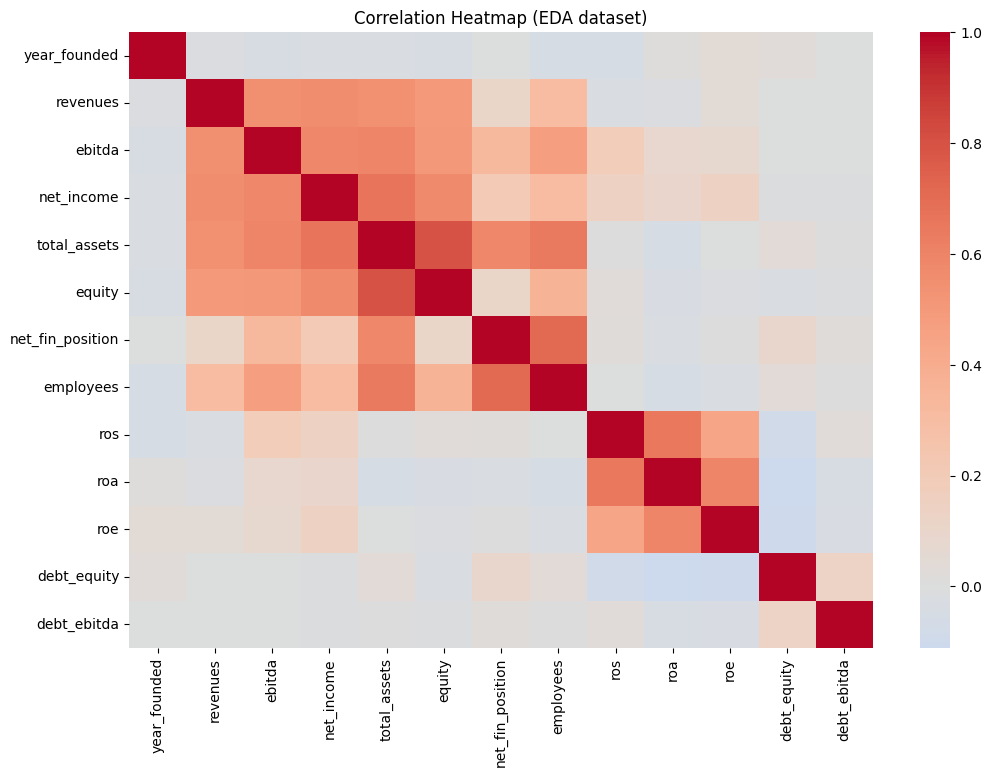

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
corr = df_eda.drop(columns=["target"]).corr()
sns.heatmap(corr, cmap="coolwarm", annot=False, center=0)
plt.title("Correlation Heatmap (EDA dataset)")
plt.show()

🔹 1. Strong Correlations (Red blocks close to 1)

Revenues, EBITDA, Net Income, Total Assets, Equity, Employees
→ All strongly correlated (0.6–0.9).

Bigger companies (high revenues, more employees) → higher assets, equity, and typically positive profits.

Makes sense: size drives financial scale.

Equity ↔ Total Assets → very strong correlation.

Companies with large assets generally have large equity (unless highly leveraged).

🔹 2. Medium Correlations

Net Financial Position (NFP) has some correlation with assets/equity but weaker.

Because leverage varies a lot: some firms borrow heavily, others stay debt-light.

Profitability Ratios (ROS, ROA, ROE)

Positively correlated with each other (0.3–0.6).

That makes sense: firms with good return on sales often also show better ROA/ROE.

🔹 3. Weak / Negative Correlations

Debt Ratios (Debt/Equity, Debt/EBITDA)

Very weak or slightly negative correlations with equity/profitability.

This indicates: high debt doesn’t always mean low equity/profits, but on average more debt tends to reduce returns.

Year Founded (company age)

Very weak correlation with everything.

Age doesn’t directly determine size or performance → both young startups and very old companies can be large/profitable.

🔹 4. Patterns to note

Your dataset is dominated by company size effects: revenues, assets, equity, and employees all cluster together.

Ratios (ROS, ROA, ROE) are a separate “profitability dimension”.

Leverage ratios (Debt/Equity, Debt/EBITDA) form their own group, largely independent.

At least 3 distinct dimensions of features:

* Size (revenues, assets, employees)

* Profitability (ROS, ROA, ROE)

* Leverage (Debt ratios, NFP)

That separation makes it easier for a classifier to detect patterns between Attiva, Insolvenza, Amministrazione.

To see whether the three legal states (Attiva, Insolvenza, Amministrazione controllata) form visible clusters in your financial space.

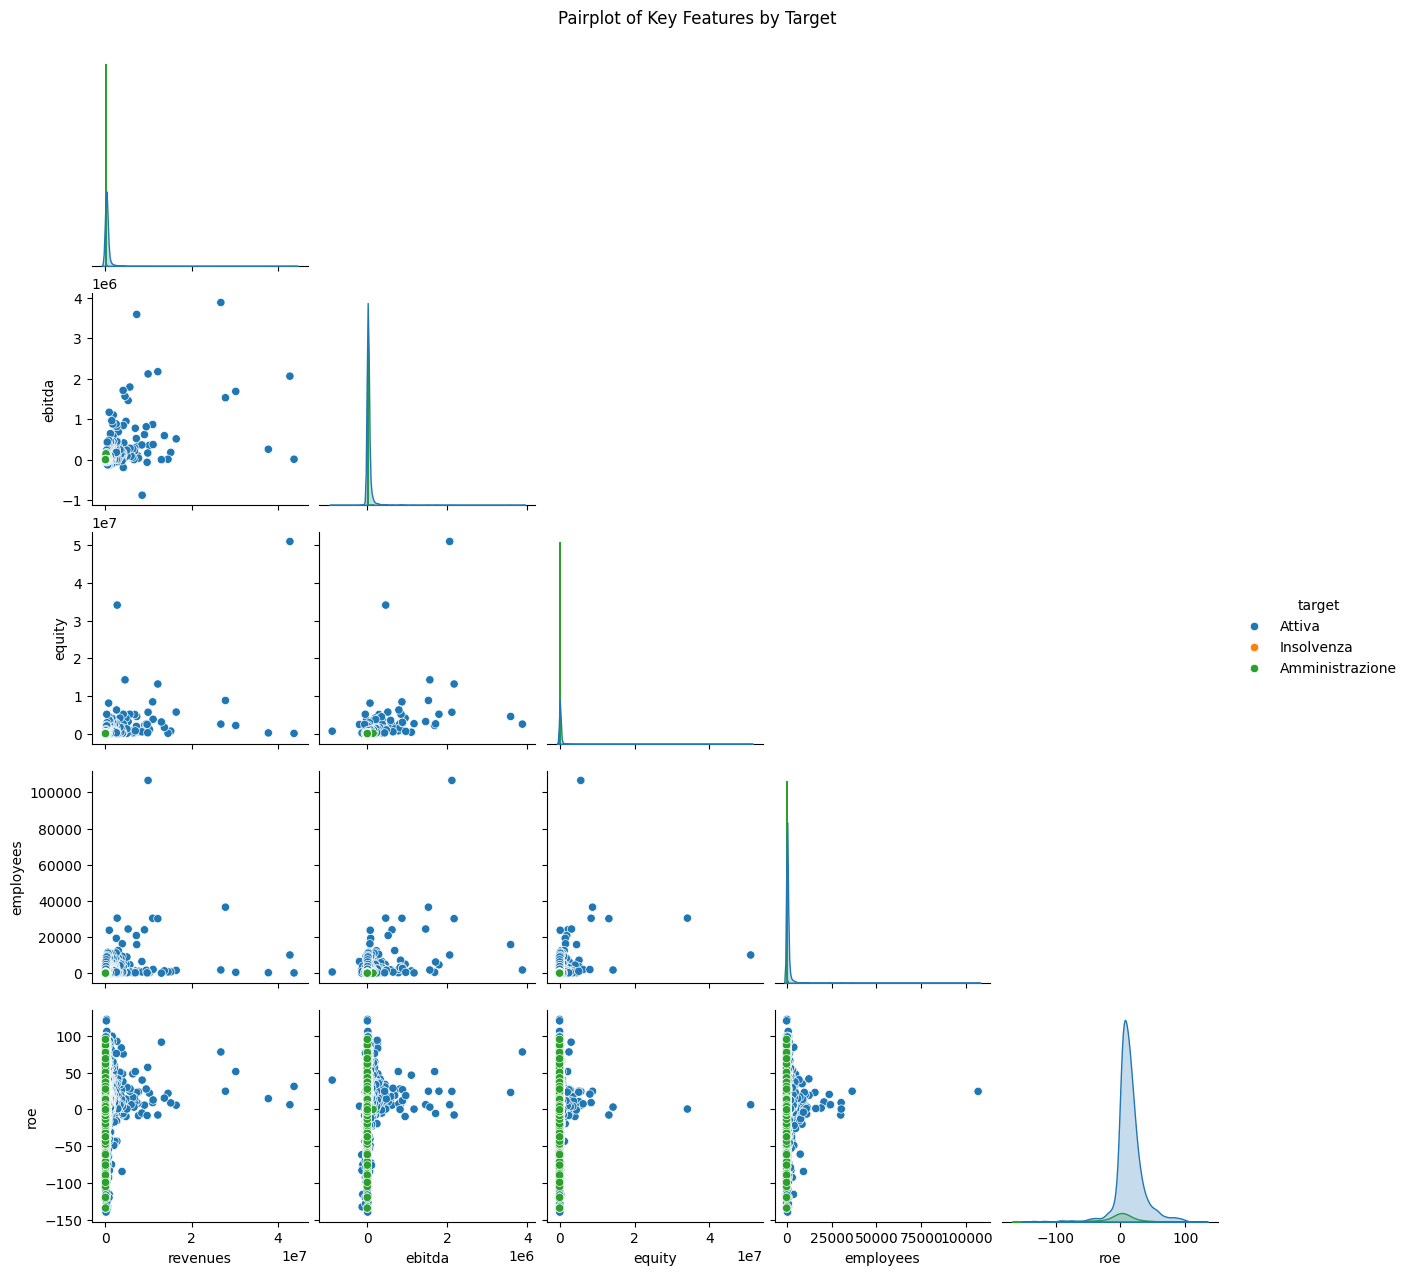

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pick a subset (too many features makes it unreadable)
subset_features = ["revenues", "ebitda", "equity", "employees", "roe"]

sns.pairplot(df_eda[subset_features + ["target"]], hue="target", diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Key Features by Target", y=1.02)
plt.show()
